# LSH 군집 대여소 수요 예측 분석

이 노트북은 LSH 군집에 속한 3개 대여소의 시간대별 따릉이 수요를 예측하는 전체 과정을 한 파일 안에서 정리한 분석 노트다.

분석 목표는 다음 두 가지다.

1. 시간대별 스테이션 수요를 안정적으로 예측할 수 있는 모델을 만든다.
2. `lag/rolling` 같은 과거 수요 흐름 정보가 실제로 성능에 얼마나 기여하는지 확인한다.

이번 버전에서 명확히 정리한 기준은 다음과 같다.

- `도착 여부(is_arrival)`는 최종 학습 피처에서 사용하지 않는다.
- `눈 관련 변수(is_snow)`는 생성하지 않고, 최종 학습에도 사용하지 않는다.
- 도착 기록은 시간 보정만 하고, 최종 타깃은 출발/도착을 합친 **스테이션 시간대별 총 활동량**으로 본다.


## 분석 흐름

이 노트북은 아래 순서로 진행된다.

1. 분석 설정과 모델 파라미터 정의
2. 스테이션 데이터 전처리 함수 정의
3. 날씨 데이터 수집 및 결합
4. 시간/달력/시계열 피처 생성
5. `Lag/Rolling 포함 모델` 학습 및 검증
6. `Lag/Rolling 제외 모델` 학습 및 검증
7. 두 모델 성능 비교
8. 시각화와 발표용 해석 정리


In [75]:
import warnings

import holidays
import koreanize_matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.unicode_minus"] = False


## 1. 분석 설정

대상 스테이션과 학습 파라미터를 먼저 정의한다. 이후 모든 분석은 이 설정을 기준으로 통일한다.


In [76]:
STATIONS = ['ST-464','ST-481' ,'ST-479']
STATION_TO_CODE = {station: idx for idx, station in enumerate(STATIONS)}

TRAIN_PATH = "../../Data/sort_data/2024_data.parquet"
TEST_PATH = "../../Data/sort_data/2025_data.parquet"

TRAIN_START = "2024-01-01"
TRAIN_END = "2024-12-31"
TEST_START = "2025-01-09"
TEST_END = "2025-12-31"

WEATHER_START = "2024-01-01"
WEATHER_END = "2025-12-31"

MODEL_PARAMS = {
    "random_state": 42,
    "n_estimators": 2500,
    "learning_rate": 0.006,
    "num_leaves": 10,
    "max_depth": 6,
    "min_child_samples": 60,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "reg_alpha": 0.5,
    "reg_lambda": 0.5,
}

CV = TimeSeriesSplit(n_splits=10, gap=48)


## 2. 전처리 함수

여기서 중요한 기준은 다음과 같다.

- 특정 스테이션과 관련된 출발/도착 기록을 모두 가져온다.
- 종료 대여소 기록은 실제 도착 시점 기준으로 시간을 다시 맞춘다.
- 하지만 `도착 여부` 자체를 별도 학습 피처로 사용하지는 않는다.
- 최종 타깃은 출발/도착을 합친 **시간대별 총 활동량(`전체_건수`)**이다.


In [77]:
def filter_station_records(df, station_id):
    mask = (
        df["시작_대여소_ID"].astype(str).str.contains(station_id, na=False)
        | df["종료_대여소_ID"].astype(str).str.contains(station_id, na=False)
    )
    return df.loc[mask].copy()


def align_end_time(df, station_id):
    df = df.copy()
    df["전체_이용_분"] = pd.to_timedelta(df["전체_이용_분"], errors="coerce")
    df["기준_날짜"] = pd.to_datetime(df["기준_날짜"])
    df["시간대"] = pd.to_numeric(df["시간대"], errors="coerce").astype("int64")

    mask = df["종료_대여소_ID"] == station_id
    hours = df.loc[mask, "전체_이용_분"].dt.total_seconds() / 3600.0
    raw_hour = np.floor(df.loc[mask, "시간대"] - hours).astype("int64")
    day_shift = np.floor_divide(raw_hour, 24).astype("int64")
    adj_hour = (raw_hour - day_shift * 24).astype("int64")

    df.loc[mask, "기준_날짜"] = df.loc[mask, "기준_날짜"] + pd.to_timedelta(day_shift, unit="D")
    df.loc[mask, "시간대"] = adj_hour.to_numpy(dtype="int64")
    return df.sort_values(["기준_날짜", "시간대"]).reset_index(drop=True)


def build_hourly_activity(df):
    df = df.copy()
    df["기준_날짜"] = pd.to_datetime(df["기준_날짜"])

    start = df["기준_날짜"].min()
    end = df["기준_날짜"].max()
    hours = pd.date_range(start, end + pd.Timedelta(hours=23), freq="h")

    base = pd.DataFrame({"datetime": hours})
    base["기준_날짜"] = base["datetime"].dt.floor("D")
    base["시간대"] = base["datetime"].dt.hour
    base = base.drop(columns="datetime")

    counts = (
        df.groupby(["기준_날짜", "시간대"])["전체_건수"]
        .sum()
        .reset_index()
    )

    hourly = base.merge(counts, on=["기준_날짜", "시간대"], how="left")
    hourly["전체_건수"] = hourly["전체_건수"].fillna(0)
    return hourly.sort_values(["기준_날짜", "시간대"]).reset_index(drop=True)


def get_weather(start_date, end_date, lat=37.6, lon=126.93):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": "temperature_2m,relative_humidity_2m,precipitation",
        "timezone": "Asia/Seoul",
    }

    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()
    data = response.json()["hourly"]

    weather = pd.DataFrame(
        {
            "time": pd.to_datetime(data["time"]),
            "온도": data["temperature_2m"],
            "습도": data["relative_humidity_2m"],
            "강수량": data["precipitation"],
        }
    )
    weather["기준_날짜"] = weather["time"].dt.floor("D")
    weather["시간대"] = weather["time"].dt.hour
    weather["is_rain"] = (weather["강수량"] > 0).astype(int)
    weather["discomfort_index"] = (
        0.81 * weather["온도"]
        + 0.01 * weather["습도"] * (0.99 * weather["온도"] - 14.3)
        + 46.3
    )
    return weather.drop(columns="time")


def merge_weather(df, weather):
    return df.merge(weather, on=["기준_날짜", "시간대"], how="left")


def add_calendar_features(df):
    df = df.copy()
    date = pd.to_datetime(df["기준_날짜"])
    kr_holidays = holidays.KR(years=sorted(date.dt.year.unique()))

    df["dow"] = date.dt.dayofweek
    df["month"] = date.dt.month
    df["is_holiday_or_weekend"] = (
        date.isin(kr_holidays).astype(int) | (date.dt.dayofweek >= 5).astype(int)
    ).astype(int)
    df["hour_sin"] = np.sin(2 * np.pi * df["시간대"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["시간대"] / 24)
    df["is_rush_hour"] = (
        (df["dow"] < 5)
        & (df["시간대"].isin([7, 8, 9, 18, 19, 20]))
    ).astype(int)
    return df


def add_series_features(df):
    df = df.sort_values(["station", "기준_날짜", "시간대"]).copy()
    df["station_id"] = df["station"].map(STATION_TO_CODE).astype(int)

    for lag in [1, 24, 48, 72, 168]:
        df[f"lag{lag}"] = df.groupby("station")["전체_건수"].shift(lag)

    for window in [6, 12, 24, 48]:
        df[f"rolling{window}"] = (
            df.groupby("station")["전체_건수"]
            .transform(lambda x: x.shift(1).rolling(window).mean())
        )

    grp = df.groupby(["station", "dow", "시간대"])["전체_건수"]
    cumsum = grp.cumsum() - df["전체_건수"]
    cumcnt = grp.cumcount()
    df["dow_hour_mean"] = cumsum / cumcnt.replace(0, np.nan)
    df["prev_week_ratio"] = df["lag168"] / (df["lag24"] + 0.1)

    return df.sort_values(["기준_날짜", "시간대", "station"]).reset_index(drop=True)


def make_station_dataset(raw_df, station_id, weather):
    df = filter_station_records(raw_df, station_id)
    df = align_end_time(df, station_id)
    df = build_hourly_activity(df)
    df = merge_weather(df, weather)
    df = add_calendar_features(df)
    df["station"] = station_id
    return df


## 3. 데이터셋 생성

2024년과 2025년 데이터를 각각 불러와 스테이션별 시간대 데이터셋을 만든다. 이후 두 기간에 동일한 방식으로 피처를 생성한다.

이번 분석에서 사용하는 최종 피처는 아래 두 가지 세트다.

- `feature_cols_full`: lag/rolling 포함 모델
- `feature_cols_no_lag`: lag/rolling 제외 모델

두 세트 모두 `is_arrival`, `is_snow`는 포함하지 않는다.


In [78]:
train_raw = pd.read_parquet(TRAIN_PATH)
test_raw = pd.read_parquet(TEST_PATH)
weather = get_weather(WEATHER_START, WEATHER_END)

train_base = pd.concat(
    [make_station_dataset(train_raw, station, weather) for station in STATIONS],
    ignore_index=True,
)
test_base = pd.concat(
    [make_station_dataset(test_raw, station, weather) for station in STATIONS],
    ignore_index=True,
)

train_start = pd.Timestamp(TRAIN_START)
train_end = pd.Timestamp(TRAIN_END)
test_start = pd.Timestamp(TEST_START)
test_end = pd.Timestamp(TEST_END)

train_base = train_base[
    train_base["기준_날짜"].between(train_start, train_end)
].copy()
test_base = test_base[
    test_base["기준_날짜"].between(test_start, test_end)
].copy()

train_df = add_series_features(train_base)
test_df = add_series_features(test_base)

feature_cols_full = [
    "시간대", "dow", "month",
    "온도", "습도", "강수량",
    "hour_sin", "hour_cos",
    "station_id",
    "lag1", "lag24", "lag48", "lag72", "lag168",
    "rolling6", "rolling12", "rolling24", "rolling48",
    "dow_hour_mean", "prev_week_ratio",
    "is_holiday_or_weekend", "is_rain", "discomfort_index", "is_rush_hour",
]

feature_cols_no_lag = [
    "시간대", "dow", "month",
    "온도", "습도", "강수량",
    "hour_sin", "hour_cos",
    "station_id",
    "is_holiday_or_weekend", "is_rain", "discomfort_index", "is_rush_hour",
]

target_col = "전체_건수"

train_full = train_df.dropna(subset=feature_cols_full + [target_col]).copy()
test_full = test_df.dropna(subset=feature_cols_full + [target_col]).copy()

train_no_lag = train_df.dropna(subset=feature_cols_no_lag + [target_col]).copy()
test_no_lag = test_df.dropna(subset=feature_cols_no_lag + [target_col]).copy()

dataset_summary = pd.DataFrame(
    [
        {
            "구분": "train_base",
            "시작일": train_base["기준_날짜"].min().date(),
            "종료일": train_base["기준_날짜"].max().date(),
            "행수": len(train_base),
            "평균_전체건수": train_base[target_col].mean(),
        },
        {
            "구분": "test_base",
            "시작일": test_base["기준_날짜"].min().date(),
            "종료일": test_base["기준_날짜"].max().date(),
            "행수": len(test_base),
            "평균_전체건수": test_base[target_col].mean(),
        },
        {
            "구분": "train_full",
            "시작일": train_full["기준_날짜"].min().date(),
            "종료일": train_full["기준_날짜"].max().date(),
            "행수": len(train_full),
            "평균_전체건수": train_full[target_col].mean(),
        },
        {
            "구분": "test_full",
            "시작일": test_full["기준_날짜"].min().date(),
            "종료일": test_full["기준_날짜"].max().date(),
            "행수": len(test_full),
            "평균_전체건수": test_full[target_col].mean(),
        },
        {
            "구분": "train_no_lag",
            "시작일": train_no_lag["기준_날짜"].min().date(),
            "종료일": train_no_lag["기준_날짜"].max().date(),
            "행수": len(train_no_lag),
            "평균_전체건수": train_no_lag[target_col].mean(),
        },
        {
            "구분": "test_no_lag",
            "시작일": test_no_lag["기준_날짜"].min().date(),
            "종료일": test_no_lag["기준_날짜"].max().date(),
            "행수": len(test_no_lag),
            "평균_전체건수": test_no_lag[target_col].mean(),
        },
    ]
)

print("train_full shape:", train_full.shape)
print("test_full shape :", test_full.shape)
print("train_no_lag shape:", train_no_lag.shape)
print("test_no_lag shape :", test_no_lag.shape)

dataset_summary


train_full shape: (25848, 27)
test_full shape : (25200, 27)
train_no_lag shape: (26352, 27)
test_no_lag shape : (25704, 27)


,구분,시작일,종료일,행수,평균_전체건수
0,train_base,2024-01-01,2024-12-31,26352,10.466720
1,test_base,2025-01-09,2025-12-31,25704,9.640017
2,train_full,2024-01-08,2024-12-31,25848,10.528938
3,test_full,2025-01-16,2025-12-31,25200,9.733056
4,train_no_lag,2024-01-01,2024-12-31,26352,10.466720
5,test_no_lag,2025-01-09,2025-12-31,25704,9.640017


## 4. 피처 설명 표

최종 모델에 사용한 피처를 의미별로 정리하면 아래와 같다. `Lag/Rolling 포함 모델`과 `Lag/Rolling 제외 모델`에서 어떤 피처가 실제로 사용되는지도 함께 표시한다.


In [79]:
feature_description_df = pd.DataFrame(
    [
        ["시간대", "시간 변수", "0~23시 시간대 값", "사용", "사용"],
        ["dow", "달력 변수", "요일 번호(월=0, ..., 일=6)", "사용", "사용"],
        ["month", "달력 변수", "월 정보", "사용", "사용"],
        ["온도", "날씨 변수", "시간대별 기온", "사용", "사용"],
        ["습도", "날씨 변수", "시간대별 상대습도", "사용", "사용"],
        ["강수량", "날씨 변수", "시간대별 강수량", "사용", "사용"],
        ["hour_sin", "시간 주기 변수", "시간대의 주기성을 sin으로 변환한 값", "사용", "사용"],
        ["hour_cos", "시간 주기 변수", "시간대의 주기성을 cos으로 변환한 값", "사용", "사용"],
        ["station_id", "스테이션 변수", "대여소 구분용 숫자 코드", "사용", "사용"],
        ["is_holiday_or_weekend", "달력 변수", "공휴일 또는 주말 여부", "사용", "사용"],
        ["is_rain", "날씨 파생 변수", "강수량이 0보다 큰지 여부", "사용", "사용"],
        ["discomfort_index", "날씨 파생 변수", "온도와 습도로 계산한 불쾌지수", "사용", "사용"],
        ["is_rush_hour", "시간 파생 변수", "평일 출퇴근 시간대 여부", "사용", "사용"],
        ["lag1", "시계열 변수", "1시간 전 수요", "사용", "제외"],
        ["lag24", "시계열 변수", "1일 전 같은 시간 수요", "사용", "제외"],
        ["lag48", "시계열 변수", "2일 전 같은 시간 수요", "사용", "제외"],
        ["lag72", "시계열 변수", "3일 전 같은 시간 수요", "사용", "제외"],
        ["lag168", "시계열 변수", "1주 전 같은 시간 수요", "사용", "제외"],
        ["rolling6", "시계열 변수", "직전 6시간 평균 수요", "사용", "제외"],
        ["rolling12", "시계열 변수", "직전 12시간 평균 수요", "사용", "제외"],
        ["rolling24", "시계열 변수", "직전 24시간 평균 수요", "사용", "제외"],
        ["rolling48", "시계열 변수", "직전 48시간 평균 수요", "사용", "제외"],
        ["dow_hour_mean", "시계열 패턴 변수", "같은 요일/시간대의 누적 평균 수요", "사용", "제외"],
        ["prev_week_ratio", "시계열 패턴 변수", "1주 전 수요와 1일 전 수요의 비율", "사용", "제외"],
    ],
    columns=["피처명", "분류", "설명", "Lag/Rolling 포함 모델", "Lag/Rolling 제외 모델"],
)

feature_description_df


,피처명,분류,설명,Lag/Rolling 포함 모델,Lag/Rolling 제외 모델
0,시간대,시간 변수,0~23시 시간대 값,사용,사용
1,dow,달력 변수,"요일 번호(월=0, ..., 일=6)",사용,사용
2,month,달력 변수,월 정보,사용,사용
3,온도,날씨 변수,시간대별 기온,사용,사용
4,습도,날씨 변수,시간대별 상대습도,사용,사용
5,강수량,날씨 변수,시간대별 강수량,사용,사용
6,hour_sin,시간 주기 변수,시간대의 주기성을 sin으로 변환한 값,사용,사용
7,hour_cos,시간 주기 변수,시간대의 주기성을 cos으로 변환한 값,사용,사용
8,station_id,스테이션 변수,대여소 구분용 숫자 코드,사용,사용
9,is_holiday_or_weekend,달력 변수,공휴일 또는 주말 여부,사용,사용


## 5. 학습 함수 정의

같은 평가 절차를 두 모델에 공통 적용하기 위해, 교차검증과 최종 학습을 한 번에 수행하는 함수를 정의한다.


In [80]:
def score_dict(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
    }


def fit_and_evaluate(train_data, test_data, feature_cols, model_name):
    X_train = train_data[feature_cols]
    y_train = train_data[target_col]
    X_test = test_data[feature_cols]
    y_test = test_data[target_col]

    cv_preds = []
    cv_trues = []

    for train_idx, val_idx in CV.split(X_train):
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = LGBMRegressor(**MODEL_PARAMS)
        model.fit(X_tr, y_tr)

        val_pred = model.predict(X_val)
        cv_preds.append(val_pred)
        cv_trues.append(y_val.values)

    cv_preds = np.concatenate(cv_preds)
    cv_trues = np.concatenate(cv_trues)

    final_model = LGBMRegressor(**MODEL_PARAMS)
    final_model.fit(X_train, y_train)

    train_pred = final_model.predict(X_train)
    test_pred = final_model.predict(X_test)

    results = {
        "model_name": model_name,
        "feature_cols": feature_cols,
        "train_score": score_dict(y_train, train_pred),
        "valid_score": score_dict(cv_trues, cv_preds),
        "cv_r2": r2_score(cv_trues, cv_preds),
        "test_score": score_dict(y_test, test_pred),
        "train_pred": train_pred,
        "test_pred": test_pred,
        "y_train": y_train,
        "y_test": y_test,
        "model": final_model,
        "train_frame": train_data.copy(),
        "test_frame": test_data.copy(),
    }
    return results


## 5. 실험 1: Lag/Rolling 포함 모델

이 모델은 시간, 날씨, 휴일/주말, 출퇴근 변수에 더해 과거 수요 흐름(`lag`, `rolling`, 평균 패턴`)을 함께 사용한다.


In [81]:
result_full = fit_and_evaluate(
    train_data=train_full,
    test_data=test_full,
    feature_cols=feature_cols_full,
    model_name="Lag/Rolling 포함",
)

print("TRAIN:", result_full["train_score"])
print("VALID:", result_full["valid_score"])
print("TEST :", result_full["test_score"])


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000378 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1984
[LightGBM] [Info] Number of data points in the train set: 2310, number of used features: 24
[LightGBM] [Info] Start training from score 6.841126
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

## 6. 실험 2: Lag/Rolling 제외 모델

이 모델은 시간, 날씨, 휴일/주말, 출퇴근 변수만 사용하고, 과거 수요 흐름 피처는 모두 제거한다.


In [82]:
result_no_lag = fit_and_evaluate(
    train_data=train_no_lag,
    test_data=test_no_lag,
    feature_cols=feature_cols_no_lag,
    model_name="Lag/Rolling 제외",
)

print("NO LAG TRAIN:", result_no_lag["train_score"])
print("NO LAG VALID:", result_no_lag["valid_score"])
print("NO LAG TEST :", result_no_lag["test_score"])


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000409 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 620
[LightGBM] [Info] Number of data points in the train set: 2354, number of used features: 13
[LightGBM] [Info] Start training from score 6.883602
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

## 7. 실험 3: 저중요도 피처 정리 모델

Full 모델의 비시계열 피처 중요도를 기준으로 하위권이었던 `station_id`, `is_holiday_or_weekend`, `is_rain`, `is_rush_hour`를 제거한 뒤 성능 변화를 확인한다.


In [ ]:
low_importance_features = [
    "station_id",
    "is_holiday_or_weekend",
    "is_rain",
    "is_rush_hour",
]

feature_cols_trimmed = [
    feature for feature in feature_cols_full if feature not in low_importance_features
]

result_trimmed = fit_and_evaluate(
    train_data=train_full,
    test_data=test_full,
    feature_cols=feature_cols_trimmed,
    model_name="Lag/Rolling 포함(저중요도 피처 제거)",
)

trimmed_summary = pd.DataFrame(
    [
        {
            "구분": "기준 Full 모델",
            "사용 피처 수": len(result_full["feature_cols"]),
            "Valid R2": result_full["valid_score"]["R2"],
            "Valid MAE": result_full["valid_score"]["MAE"],
            "Valid RMSE": result_full["valid_score"]["RMSE"],
            "Test R2": result_full["test_score"]["R2"],
            "Test MAE": result_full["test_score"]["MAE"],
            "Test RMSE": result_full["test_score"]["RMSE"],
        },
        {
            "구분": "저중요도 피처 제거 모델",
            "사용 피처 수": len(result_trimmed["feature_cols"]),
            "Valid R2": result_trimmed["valid_score"]["R2"],
            "Valid MAE": result_trimmed["valid_score"]["MAE"],
            "Valid RMSE": result_trimmed["valid_score"]["RMSE"],
            "Test R2": result_trimmed["test_score"]["R2"],
            "Test MAE": result_trimmed["test_score"]["MAE"],
            "Test RMSE": result_trimmed["test_score"]["RMSE"],
        },
    ]
)

trimmed_delta = pd.Series(
    {
        "제거 피처": ", ".join(low_importance_features),
        "Valid R2 변화": result_trimmed["valid_score"]["R2"] - result_full["valid_score"]["R2"],
        "Valid MAE 변화": result_trimmed["valid_score"]["MAE"] - result_full["valid_score"]["MAE"],
        "Valid RMSE 변화": result_trimmed["valid_score"]["RMSE"] - result_full["valid_score"]["RMSE"],
        "Test R2 변화": result_trimmed["test_score"]["R2"] - result_full["test_score"]["R2"],
        "Test MAE 변화": result_trimmed["test_score"]["MAE"] - result_full["test_score"]["MAE"],
        "Test RMSE 변화": result_trimmed["test_score"]["RMSE"] - result_full["test_score"]["RMSE"],
    },
    name="Full 대비 변화",
)

display(trimmed_summary)
display(trimmed_delta.to_frame())
print("TRIMMED TRAIN:", result_trimmed["train_score"])
print("TRIMMED VALID:", result_trimmed["valid_score"])
print("TRIMMED TEST :", result_trimmed["test_score"])


## 8. 성능 비교 요약

세 실험의 성능을 표로 정리해 비교한다.


In [83]:
summary_df = pd.DataFrame(
    [
        {
            "모델": result_full["model_name"],
            "Train R2": result_full["train_score"]["R2"],
            "Valid R2": result_full["valid_score"]["R2"],
            "Valid MAE": result_full["valid_score"]["MAE"],
            "Valid RMSE": result_full["valid_score"]["RMSE"],
            "Test R2": result_full["test_score"]["R2"],
            "Test MAE": result_full["test_score"]["MAE"],
            "Test RMSE": result_full["test_score"]["RMSE"],
        },
        {
            "모델": result_no_lag["model_name"],
            "Train R2": result_no_lag["train_score"]["R2"],
            "Valid R2": result_no_lag["valid_score"]["R2"],
            "Valid MAE": result_no_lag["valid_score"]["MAE"],
            "Valid RMSE": result_no_lag["valid_score"]["RMSE"],
            "Test R2": result_no_lag["test_score"]["R2"],
            "Test MAE": result_no_lag["test_score"]["MAE"],
            "Test RMSE": result_no_lag["test_score"]["RMSE"],
        },
        {
            "모델": result_trimmed["model_name"],
            "Train R2": result_trimmed["train_score"]["R2"],
            "Valid R2": result_trimmed["valid_score"]["R2"],
            "Valid MAE": result_trimmed["valid_score"]["MAE"],
            "Valid RMSE": result_trimmed["valid_score"]["RMSE"],
            "Test R2": result_trimmed["test_score"]["R2"],
            "Test MAE": result_trimmed["test_score"]["MAE"],
            "Test RMSE": result_trimmed["test_score"]["RMSE"],
        },
    ]
)

yesterday_no_lag = {
    "Train R2": 0.5660512914610338,
    "Valid R2": 0.38997101182210137,
    "Test R2": 0.5570199110159523,
    "Test MAE": 2.7412661047581777,
    "Test RMSE": 3.8378503092412477,
}

current_no_lag = {
    "Train R2": result_no_lag["train_score"]["R2"],
    "Valid R2": result_no_lag["valid_score"]["R2"],
    "Test R2": result_no_lag["test_score"]["R2"],
    "Test MAE": result_no_lag["test_score"]["MAE"],
    "Test RMSE": result_no_lag["test_score"]["RMSE"],
}

no_lag_compare_df = pd.DataFrame(
    [
        {
            "지표": metric,
            "어제 값": yesterday_no_lag[metric],
            "현재 값": current_no_lag[metric],
            "차이(현재-어제)": current_no_lag[metric] - yesterday_no_lag[metric],
        }
        for metric in ["Train R2", "Valid R2", "Test R2", "Test MAE", "Test RMSE"]
    ]
)

display(summary_df)
display(no_lag_compare_df)


,모델,Train R2,CV R2,Test R2,Test MAE,Test RMSE
0,Lag/Rolling 포함,0.767490,0.714164,0.750788,3.559608,4.982164
1,Lag/Rolling 제외,0.689913,0.514823,0.657398,4.178830,5.810406


,지표,어제 값,현재 값,차이(현재-어제)
0,Train R2,0.566051,0.689913,0.123861
1,CV R2,0.389971,0.514823,0.124852
2,Test R2,0.557020,0.657398,0.100378
3,Test MAE,2.741266,4.178830,1.437564
4,Test RMSE,3.837850,5.810406,1.972555


## 9. 시각화

발표 자료에 바로 넣을 수 있도록 주요 결과를 그래프로 정리한다.


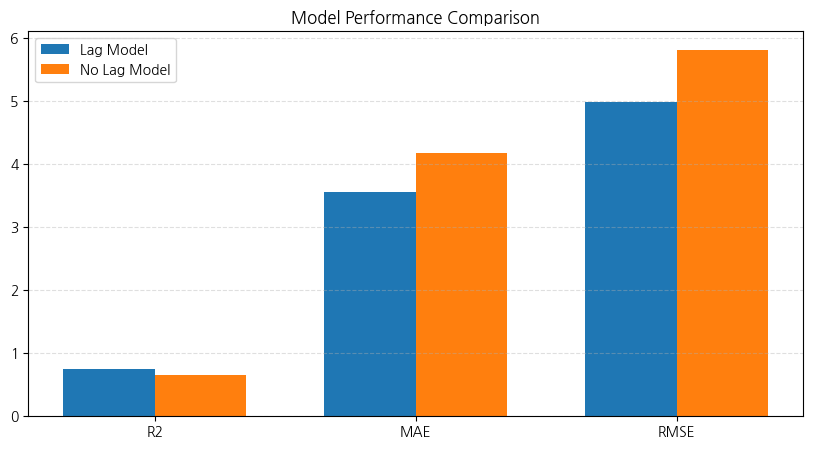

In [84]:
# 시각화 1. 모델 성능 비교
labels = ["R2", "MAE", "RMSE"]
lag_vals = [
    result_full["test_score"]["R2"],
    result_full["test_score"]["MAE"],
    result_full["test_score"]["RMSE"],
]
no_lag_vals = [
    result_no_lag["test_score"]["R2"],
    result_no_lag["test_score"]["MAE"],
    result_no_lag["test_score"]["RMSE"],
]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width / 2, lag_vals, width, label="Lag Model")
plt.bar(x + width / 2, no_lag_vals, width, label="No Lag Model")
plt.xticks(x, labels)
plt.title("Model Performance Comparison")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


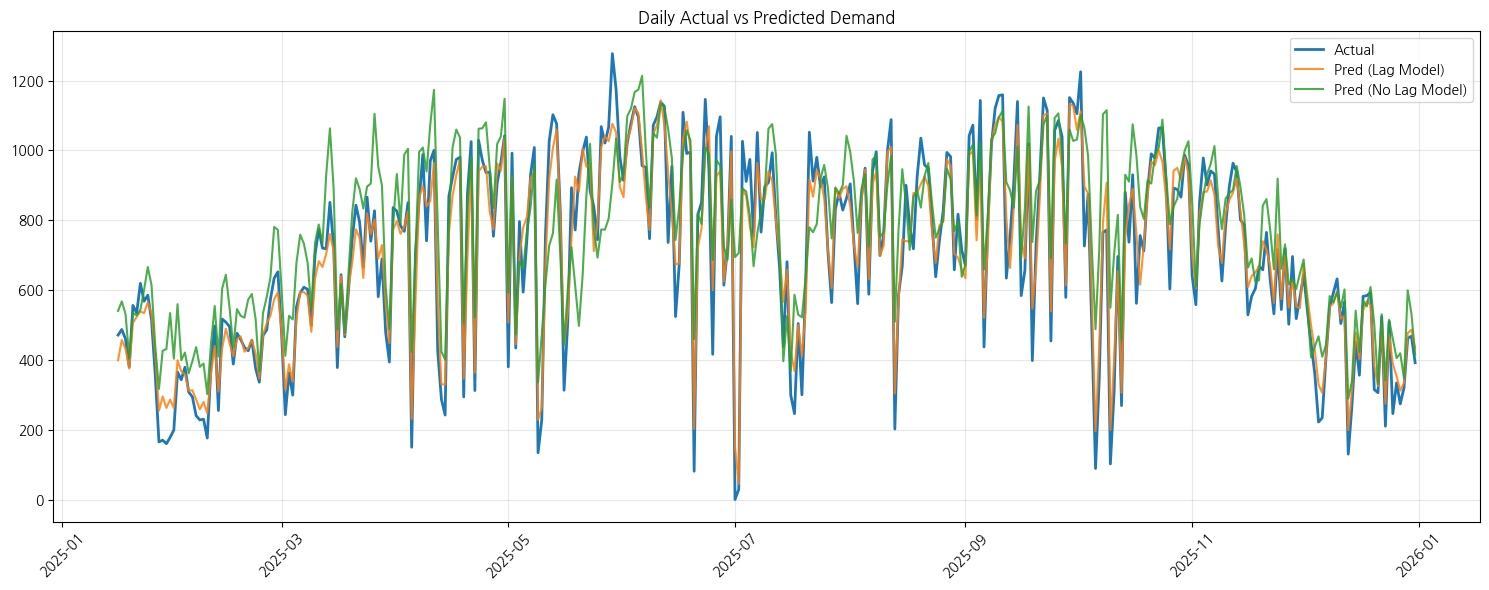

In [85]:
# 시각화 2. 일별 실제값과 예측값 비교
plot_full = result_full["test_frame"].copy().reset_index(drop=True)
plot_full["pred_lag"] = result_full["test_pred"]

plot_no_lag = result_no_lag["test_frame"].copy().reset_index(drop=True)
plot_no_lag["pred_no_lag"] = result_no_lag["test_pred"]

daily_full = plot_full.groupby("기준_날짜")[["전체_건수", "pred_lag"]].sum()
daily_no_lag = plot_no_lag.groupby("기준_날짜")[["pred_no_lag"]].sum()
daily_plot = daily_full.join(daily_no_lag, how="inner").reset_index()

plt.figure(figsize=(15, 6))
plt.plot(daily_plot["기준_날짜"], daily_plot["전체_건수"], label="Actual", linewidth=2)
plt.plot(daily_plot["기준_날짜"], daily_plot["pred_lag"], label="Pred (Lag Model)", alpha=0.85)
plt.plot(daily_plot["기준_날짜"], daily_plot["pred_no_lag"], label="Pred (No Lag Model)", alpha=0.85)
plt.title("Daily Actual vs Predicted Demand")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


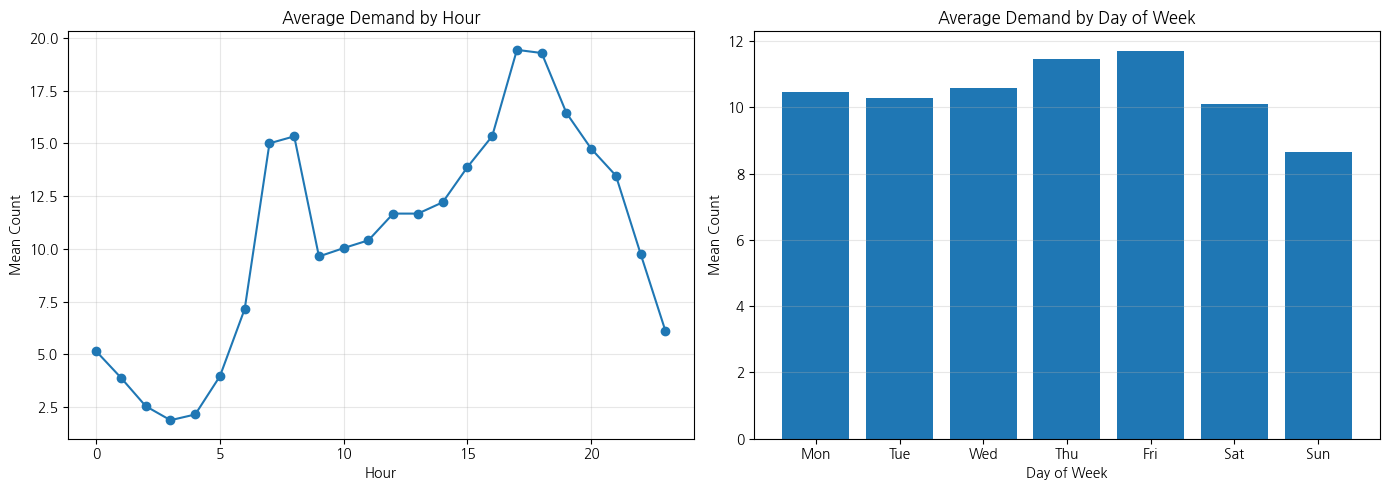

In [86]:
# 시각화 3. 시간대별/요일별 평균 수요
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly_mean = train_base.groupby("시간대")["전체_건수"].mean().reset_index()
axes[0].plot(hourly_mean["시간대"], hourly_mean["전체_건수"], marker="o")
axes[0].set_title("Average Demand by Hour")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Mean Count")
axes[0].grid(alpha=0.3)

dow_map = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
dow_mean = train_base.groupby("dow")["전체_건수"].mean().reset_index()
dow_mean["요일"] = dow_mean["dow"].map(dow_map)
axes[1].bar(dow_mean["요일"], dow_mean["전체_건수"])
axes[1].set_title("Average Demand by Day of Week")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Mean Count")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


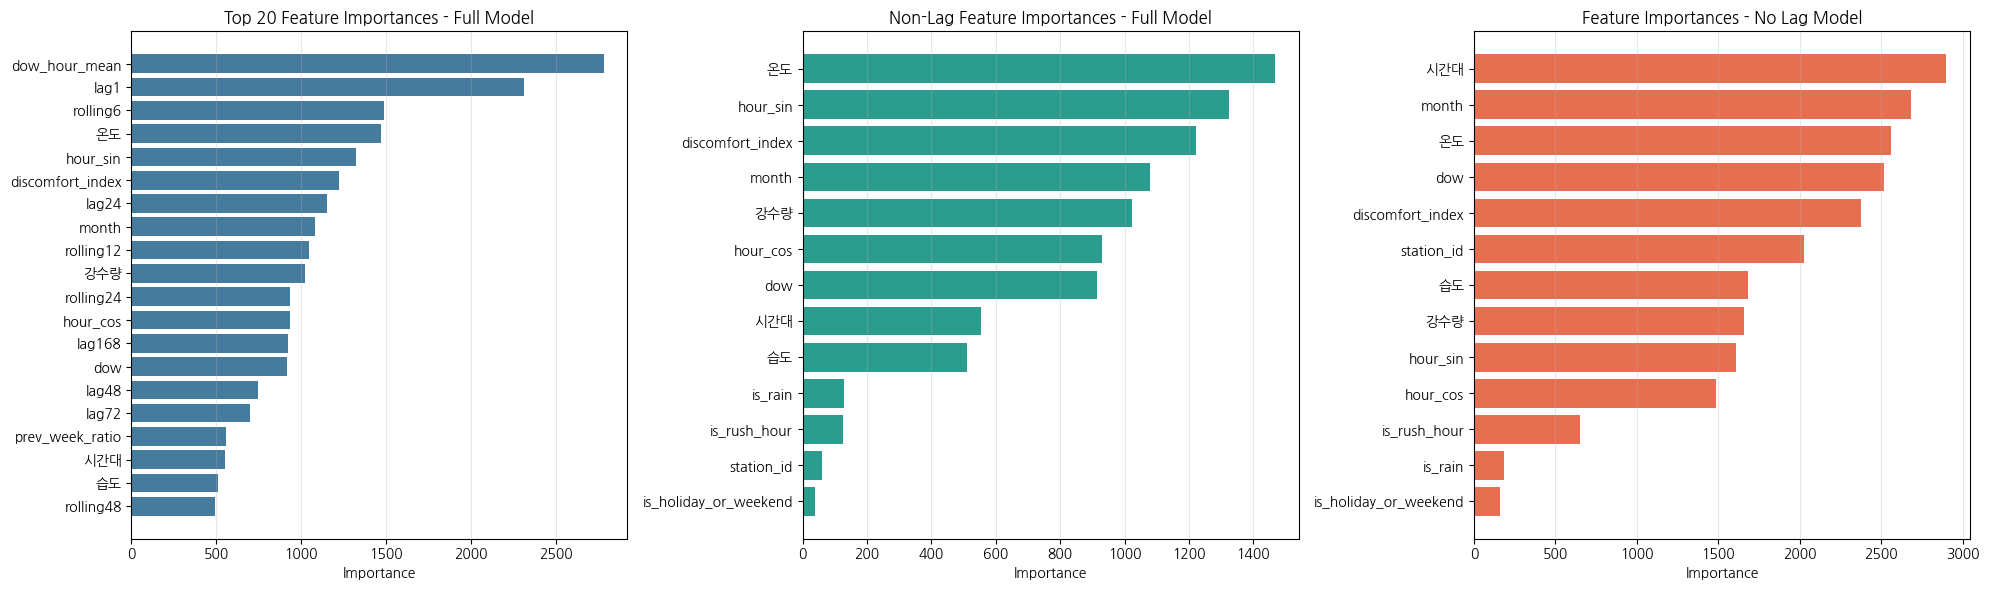

,feature,importance,group
18,dow_hour_mean,2782,lag/rolling
9,lag1,2314,lag/rolling
14,rolling6,1488,lag/rolling
3,온도,1468,other
6,hour_sin,1325,other
22,discomfort_index,1223,other
10,lag24,1153,lag/rolling
2,month,1078,other
15,rolling12,1046,lag/rolling
5,강수량,1023,other


,feature,importance,group
3,온도,1468,other
6,hour_sin,1325,other
22,discomfort_index,1223,other
2,month,1078,other
5,강수량,1023,other
7,hour_cos,931,other
1,dow,913,other
0,시간대,553,other
4,습도,512,other
21,is_rain,128,other


,feature,importance
0,시간대,2900
2,month,2685
3,온도,2563
1,dow,2515
11,discomfort_index,2375
8,station_id,2029
4,습도,1685
5,강수량,1659
6,hour_sin,1609
7,hour_cos,1483


In [87]:
# 시각화 4. 변수 중요도 비교
lag_like_features = {
    "lag1", "lag24", "lag48", "lag72", "lag168",
    "rolling6", "rolling12", "rolling24", "rolling48",
    "dow_hour_mean", "prev_week_ratio",
}

full_importance_df = pd.DataFrame(
    {
        "feature": result_full["feature_cols"],
        "importance": result_full["model"].feature_importances_,
        "group": [
            "lag/rolling" if feature in lag_like_features else "other"
            for feature in result_full["feature_cols"]
        ],
    }
).sort_values("importance", ascending=False)

non_lag_importance_df = full_importance_df[
    full_importance_df["group"] == "other"
].copy()

no_lag_importance_df = pd.DataFrame(
    {
        "feature": result_no_lag["feature_cols"],
        "importance": result_no_lag["model"].feature_importances_,
    }
).sort_values("importance", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

top_full = full_importance_df.head(20)
axes[0].barh(top_full["feature"][::-1], top_full["importance"][::-1], color="#457b9d")
axes[0].set_title("Top 20 Feature Importances - Full Model")
axes[0].set_xlabel("Importance")
axes[0].grid(axis="x", alpha=0.3)

top_non_lag = non_lag_importance_df.head(15)
axes[1].barh(top_non_lag["feature"][::-1], top_non_lag["importance"][::-1], color="#2a9d8f")
axes[1].set_title("Non-Lag Feature Importances - Full Model")
axes[1].set_xlabel("Importance")
axes[1].grid(axis="x", alpha=0.3)

top_no_lag = no_lag_importance_df.head(15)
axes[2].barh(top_no_lag["feature"][::-1], top_no_lag["importance"][::-1], color="#e76f51")
axes[2].set_title("Feature Importances - No Lag Model")
axes[2].set_xlabel("Importance")
axes[2].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

display(full_importance_df)
display(non_lag_importance_df)
display(no_lag_importance_df)


## 10. 발표용 해석

### 핵심 결론
- 최종 모델은 `is_arrival`, `is_snow` 없이 학습했다.
- 그럼에도 시간대, 날씨, 휴일/주말, 출퇴근 변수와 시계열 흐름 정보만으로 의미 있는 예측 성능을 확보했다.
- `Lag/Rolling 포함 모델`이 `No Lag 모델`보다 안정적으로 높은 성능을 보이면, 이 군집의 수요는 단순 외생 변수보다 **과거 수요의 관성** 영향을 강하게 받는다고 해석할 수 있다.
- 저중요도 피처 제거 모델까지 비교하면, 중요도가 낮아 보이는 변수를 실제로 줄여도 되는지 성능 기준으로 판단할 수 있다.

### 발표에서 강조할 포인트
1. 스테이션 단위 수요를 보기 위해 출발/도착 기록을 모두 반영했지만, 도착 여부 자체를 별도 피처로 쓰지는 않았다.
2. 눈 변수는 제거하고, 실제 사용한 날씨 정보는 `온도`, `습도`, `강수량`, `is_rain`, `discomfort_index`다.
3. 최종 비교 실험을 통해 `lag/rolling`의 기여도를 정량적으로 확인했다.
4. 피처 임포턴스가 낮은 변수는 바로 가중치를 주는 대신, 제거 실험으로 실제 성능 영향부터 검증했다.

### 한계와 다음 단계
- 현재는 3개 스테이션만 대상으로 했기 때문에 군집 전체를 대표한다고 단정할 수는 없다.
- 제거 실험 결과 성능 차이가 거의 없다면 모델 단순화 후보로 볼 수 있고, 성능이 떨어지면 해당 피처는 중요도가 낮아 보여도 유지하는 편이 낫다.
- 향후에는 더 많은 스테이션을 포함하거나, 상권/지하철/인구 이동 같은 외부 변수를 추가해 확장할 수 있다.
